In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
# Load MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)   
print("y_train shape:", y_train.shape)   
print("X_test shape:", X_test.shape)     
print("y_test shape:", y_test.shape)   

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
# Load fresh raw MNIST data (NOT normalized)
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

# Create save folder
save_folder = "mnist_digits"
os.makedirs(save_folder, exist_ok=True)

saved_digits = {}

for i in range(len(X_train_raw)):
    digit = y_train[i]

    if digit not in saved_digits:
        image = X_train_raw[i]   # already shape (28,28), uint8

        img = Image.fromarray(image, mode='L')
        file_path = os.path.join(save_folder, f"digit_{digit}.png")
        img.save(file_path)

        saved_digits[digit] = file_path
        print(f"Saved: {file_path}")

    if len(saved_digits) == 10:
        break

print("\nAll digits 0 to 9 saved successfully!")

Saved: mnist_digits\digit_5.png
Saved: mnist_digits\digit_0.png
Saved: mnist_digits\digit_4.png
Saved: mnist_digits\digit_1.png
Saved: mnist_digits\digit_9.png
Saved: mnist_digits\digit_2.png
Saved: mnist_digits\digit_3.png
Saved: mnist_digits\digit_6.png
Saved: mnist_digits\digit_7.png
Saved: mnist_digits\digit_8.png

All digits 0 to 9 saved successfully!


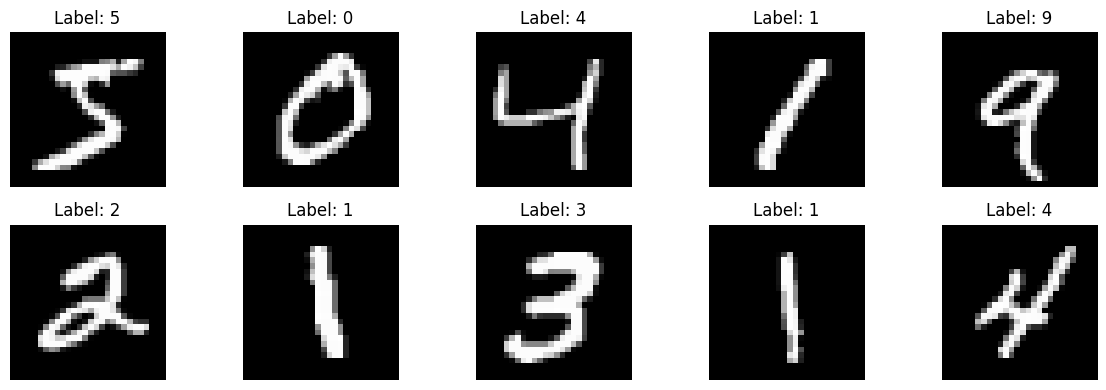

In [6]:
# Show sample images

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Preprocess data (VERY IMPORTANT)
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# Reshape for CNN: (samples, height, width, channels)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print("X_train shape:", X_train.shape)  
print("X_test shape:", X_test.shape)     
print("X_train min/max:", X_train.min(), X_train.max())

After preprocessing:
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
X_train min/max: 0.0 1.0


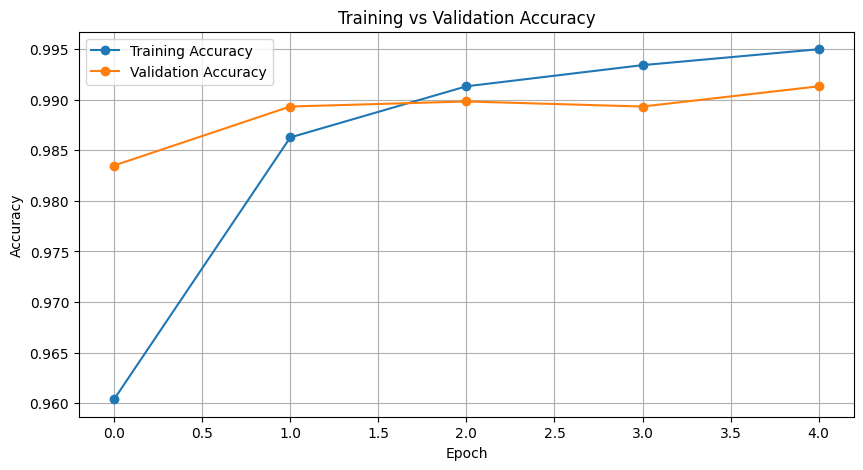

In [18]:
# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Build CNN model

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')   # 10 classes: 0 to 9
])

model.summary()

c:\Users\SUNIL\OneDrive\Desktop\Data_Science\demo1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Train model

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9604 - loss: 0.1326 - val_accuracy: 0.9835 - val_loss: 0.0518
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9863 - loss: 0.0443 - val_accuracy: 0.9893 - val_loss: 0.0393
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9913 - loss: 0.0287 - val_accuracy: 0.9898 - val_loss: 0.0355
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9934 - loss: 0.0207 - val_accuracy: 0.9893 - val_loss: 0.0385
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9913 - val_loss: 0.0360


In [ ]:
# Evaluate model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0322
Test Loss: 0.03219721466302872
Test Accuracy: 0.9901000261306763
Test Accuracy (%): 99.01000261306763


In [ ]:
# Save model correctly

model.save("mnist_cnn_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Test prediction on actual MNIST test images
# Test first 10 images from X_test

predictions = model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels   :", y_test[:10])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Actual labels   : [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 5 9]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


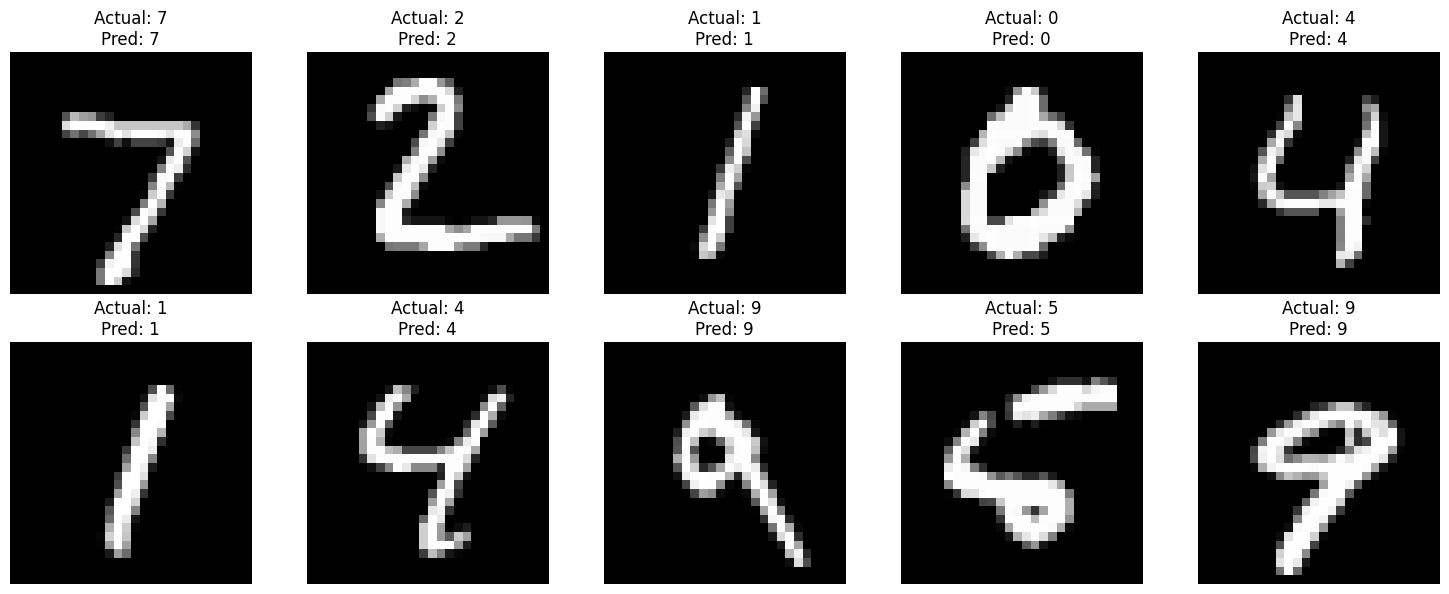

In [ ]:
# Visual test (best check)

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    pred = np.argmax(model.predict(X_test[i:i+1]), axis=1)[0]
    actual = y_test[i]
    
    plt.title(f"Actual: {actual}\nPred: {pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
loaded_model = tf.keras.models.load_model("mnist_cnn_model.keras", compile=False)

predictions = loaded_model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels   :", y_test[:10])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Actual labels   : [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 5 9]
